# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [ ]:
17 marketing campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score, precision_recall_curve, roc_curve
import time

from sklearn import set_config
set_config(display='diagram')

import warnings
warnings.filterwarnings('ignore')


In [3]:
!pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo

bank_marketing= fetch_ucirepo(id=222)
df= bank_marketing.data.original
print(df.head())


   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Understanding the Features : Preliminary Conclusion
The data set is complete and does not have any N/A or null numbers.
There are 10 Categorical and 7 numerical variables.
Within the categorical features we have 3 Binary features ; 'default','housing', 'loan'.

**EXPLORE THE DISTRIBUTION OF THE DATASET**

['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


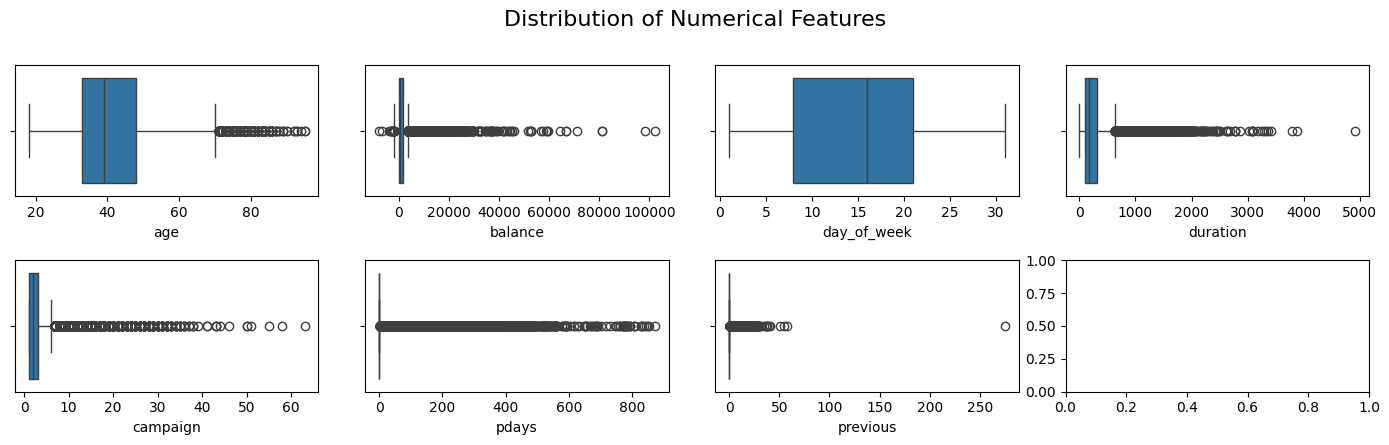

In [8]:
num_column_1st= []
for icol in df.columns:
    if df[icol].dtypes in ['float64','int64']:
       num_column_1st.append(icol)
print(num_column_1st)

fig,axs= plt.subplots(nrows=2, ncols=4, figsize=(14,4))
for name, ax in zip(num_column_1st, axs.flatten()):
    sns.boxplot(data=df, x=name, ax=ax)

fig.tight_layout()
fig.suptitle('Distribution of Numerical Features',y= 1.1, fontsize=16)
plt.show()



Duration seems to have long calls. This may be that as you onboard clients the calls extend since there needs to be further information exchanged. This could have an important impact to monitor  the predictive model.  

Campaign represents the number of attempted contact during a specific campaign. The majority of the contacts respond within the first few attempts with some requiring repeated contacts.
The pdays, the data set has over 999 days in over 75%, which will carry meaning pertaining to the latest campaign and not future campaigns. I will consider dropping this variable. 'previous' also monitors the number of times people were contacted before the campaign. Since over 75% of the data is 0 times, I will consider dropping this variable.

**Explore the distribution through Bar plots**

Text(0.5, 1.1, 'Distribution Plot of Numerical Features')

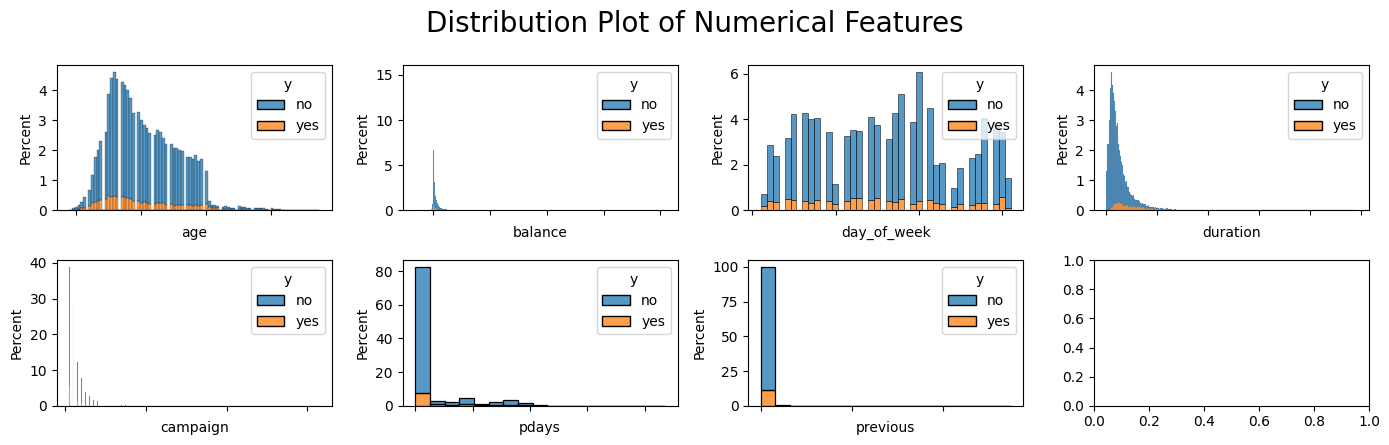

In [9]:
fig,axs= plt.subplots(nrows=2, ncols=4, figsize=(14,4))
for name, ax in zip(num_column_1st, axs.flatten()):
    sns.histplot(data=df, x=name, ax=ax, hue='y', multiple = 'stack', stat= 'percent')
    ax.set_xticklabels(ax.get_xticklabels(minor=True, which= 'minor'), rotation=0, fontsize=50)


fig.tight_layout()
fig.suptitle('Distribution Plot of Numerical Features',y= 1.1, fontsize=20)

Many distrutions have skewed and will need to be scaled. The feature 'pdays', I believe we should drop the variable  as little significance will be extracted from this variable.

Correlation Matrix of the numerical features

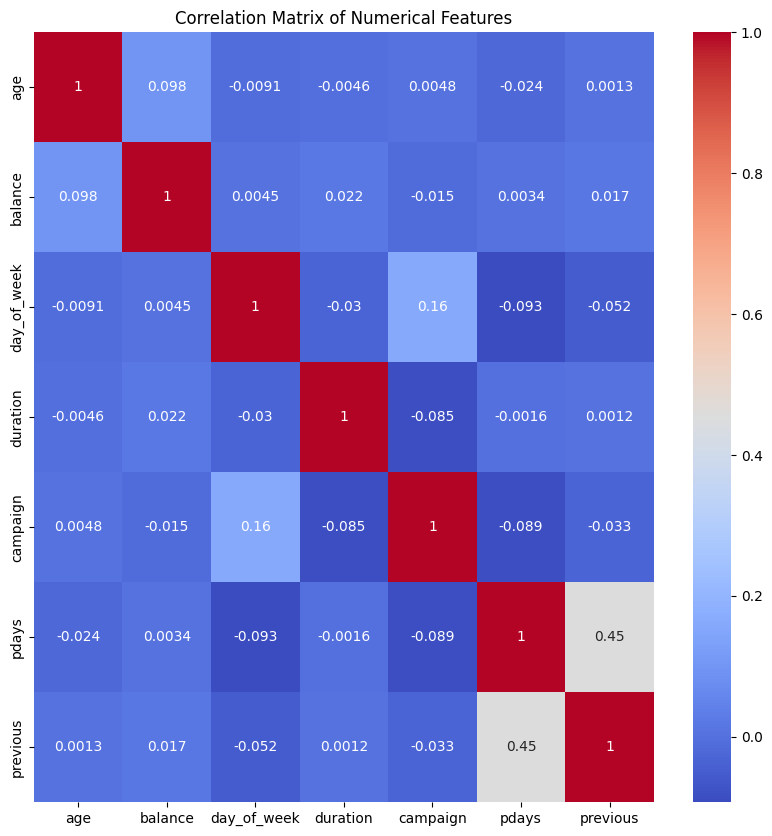

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(df[num_column_1st].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Text(0.5, 1.0, 'Pairplot of the numerical features')

<Figure size 1000x1000 with 0 Axes>

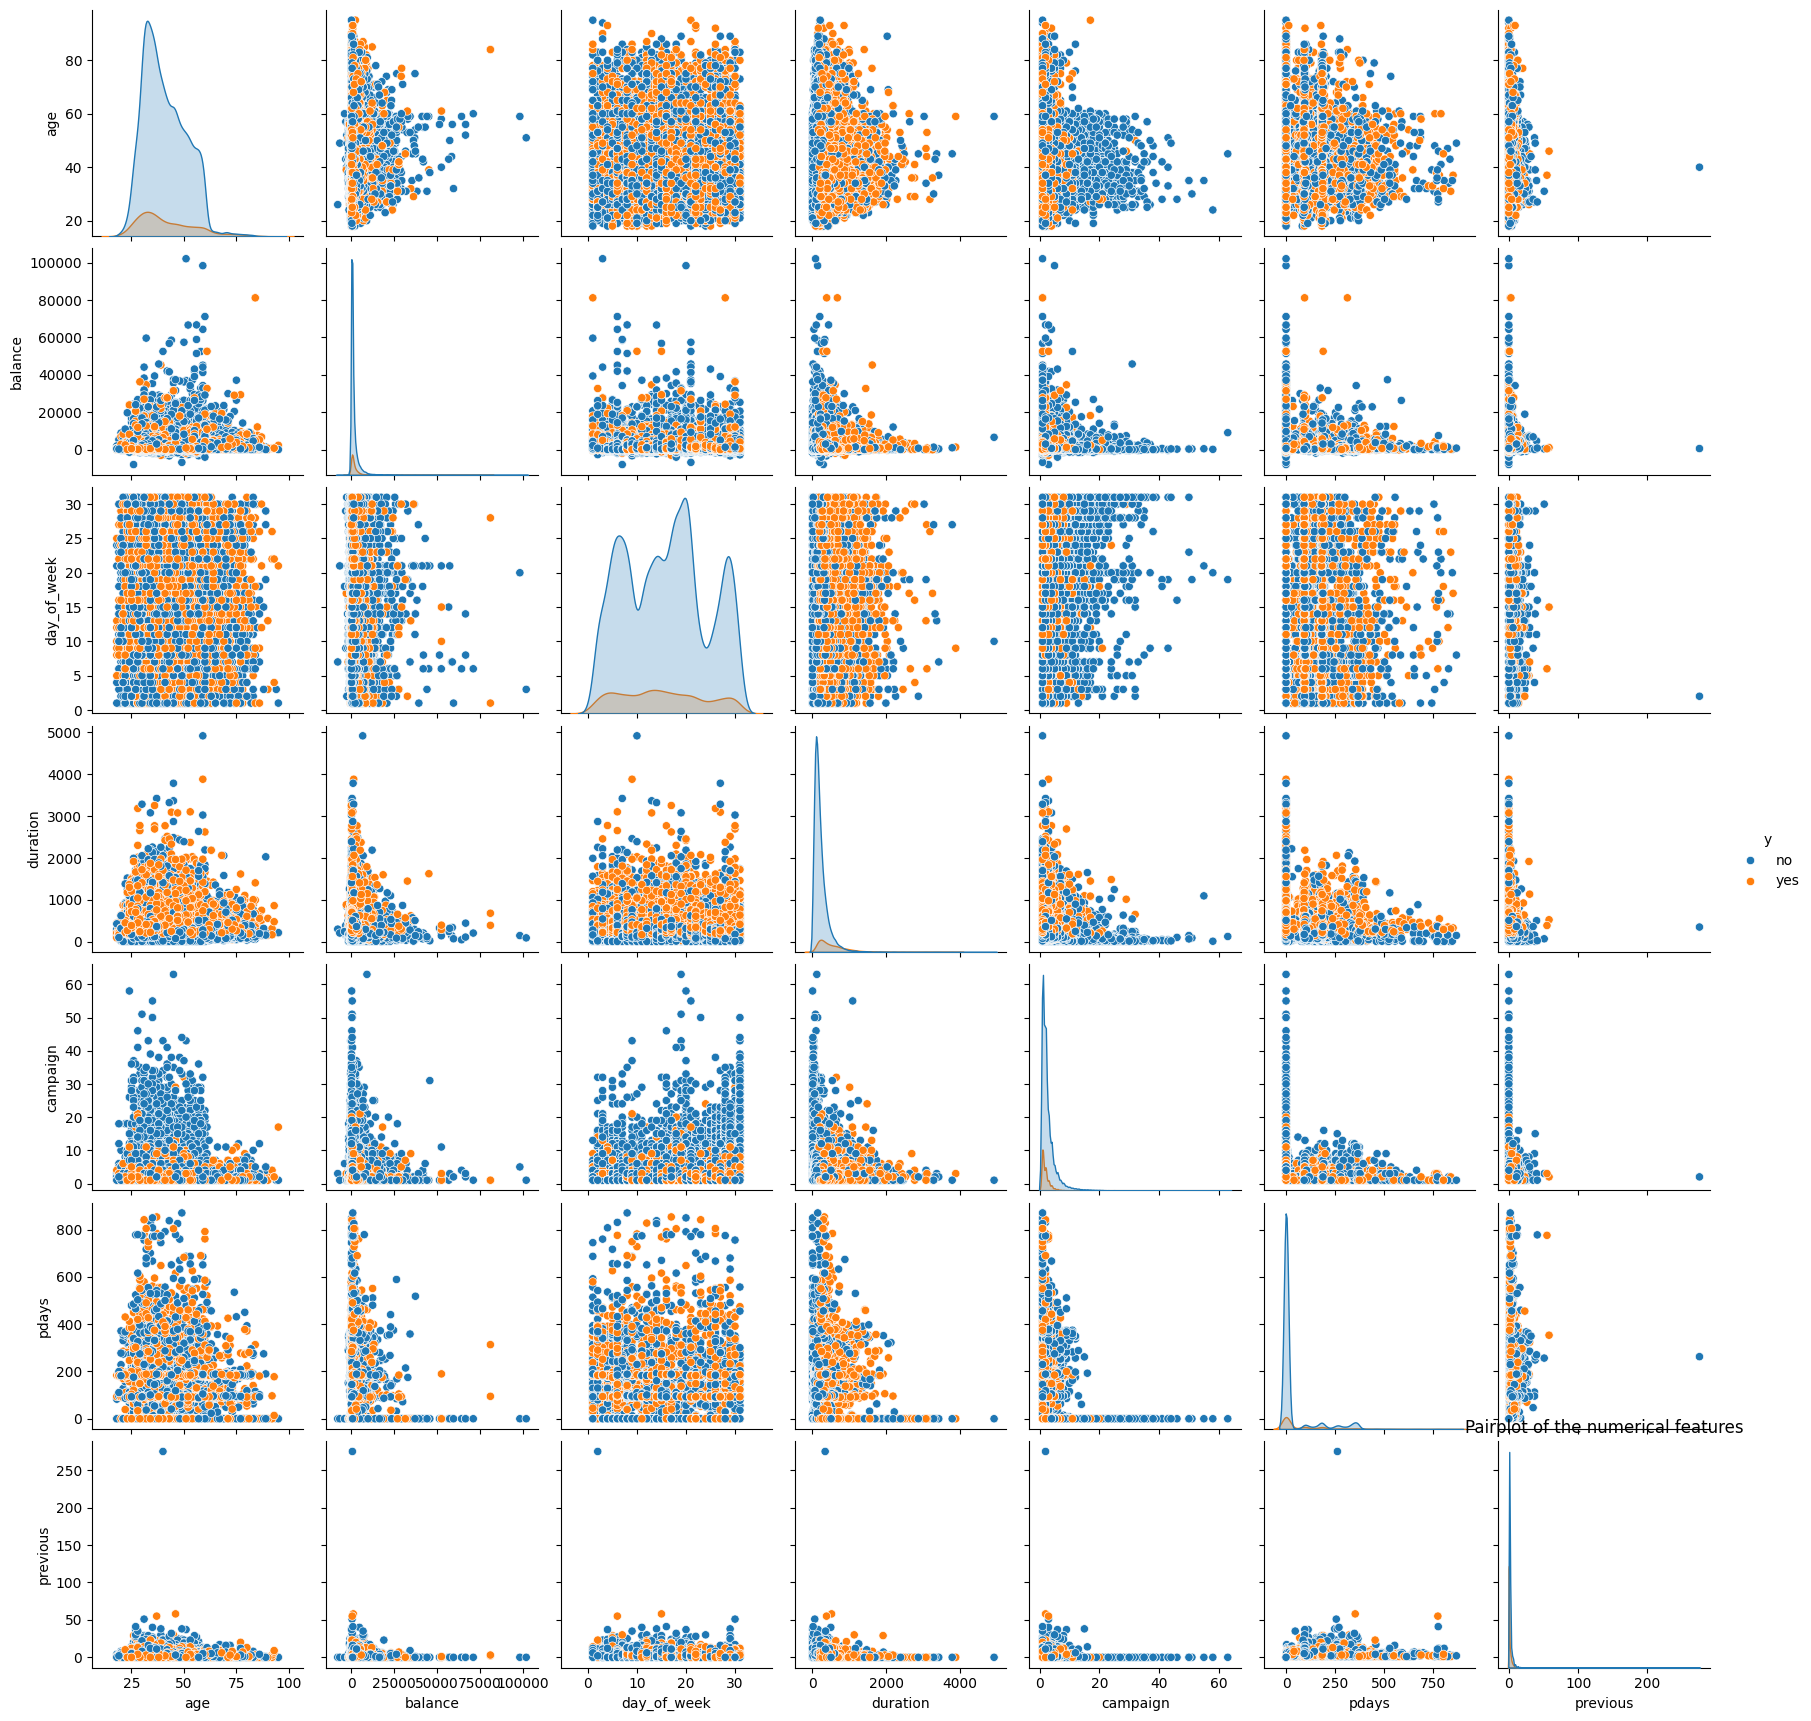

In [11]:
plt.figure(figsize=(10,10))
sns.pairplot(data=df, hue= 'y')
plt.title ('Pairplot of the numerical features')

**Categorical Features Investigation**

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


Text(0.5, 1.1, 'Distribution Plot of Categorical Features')

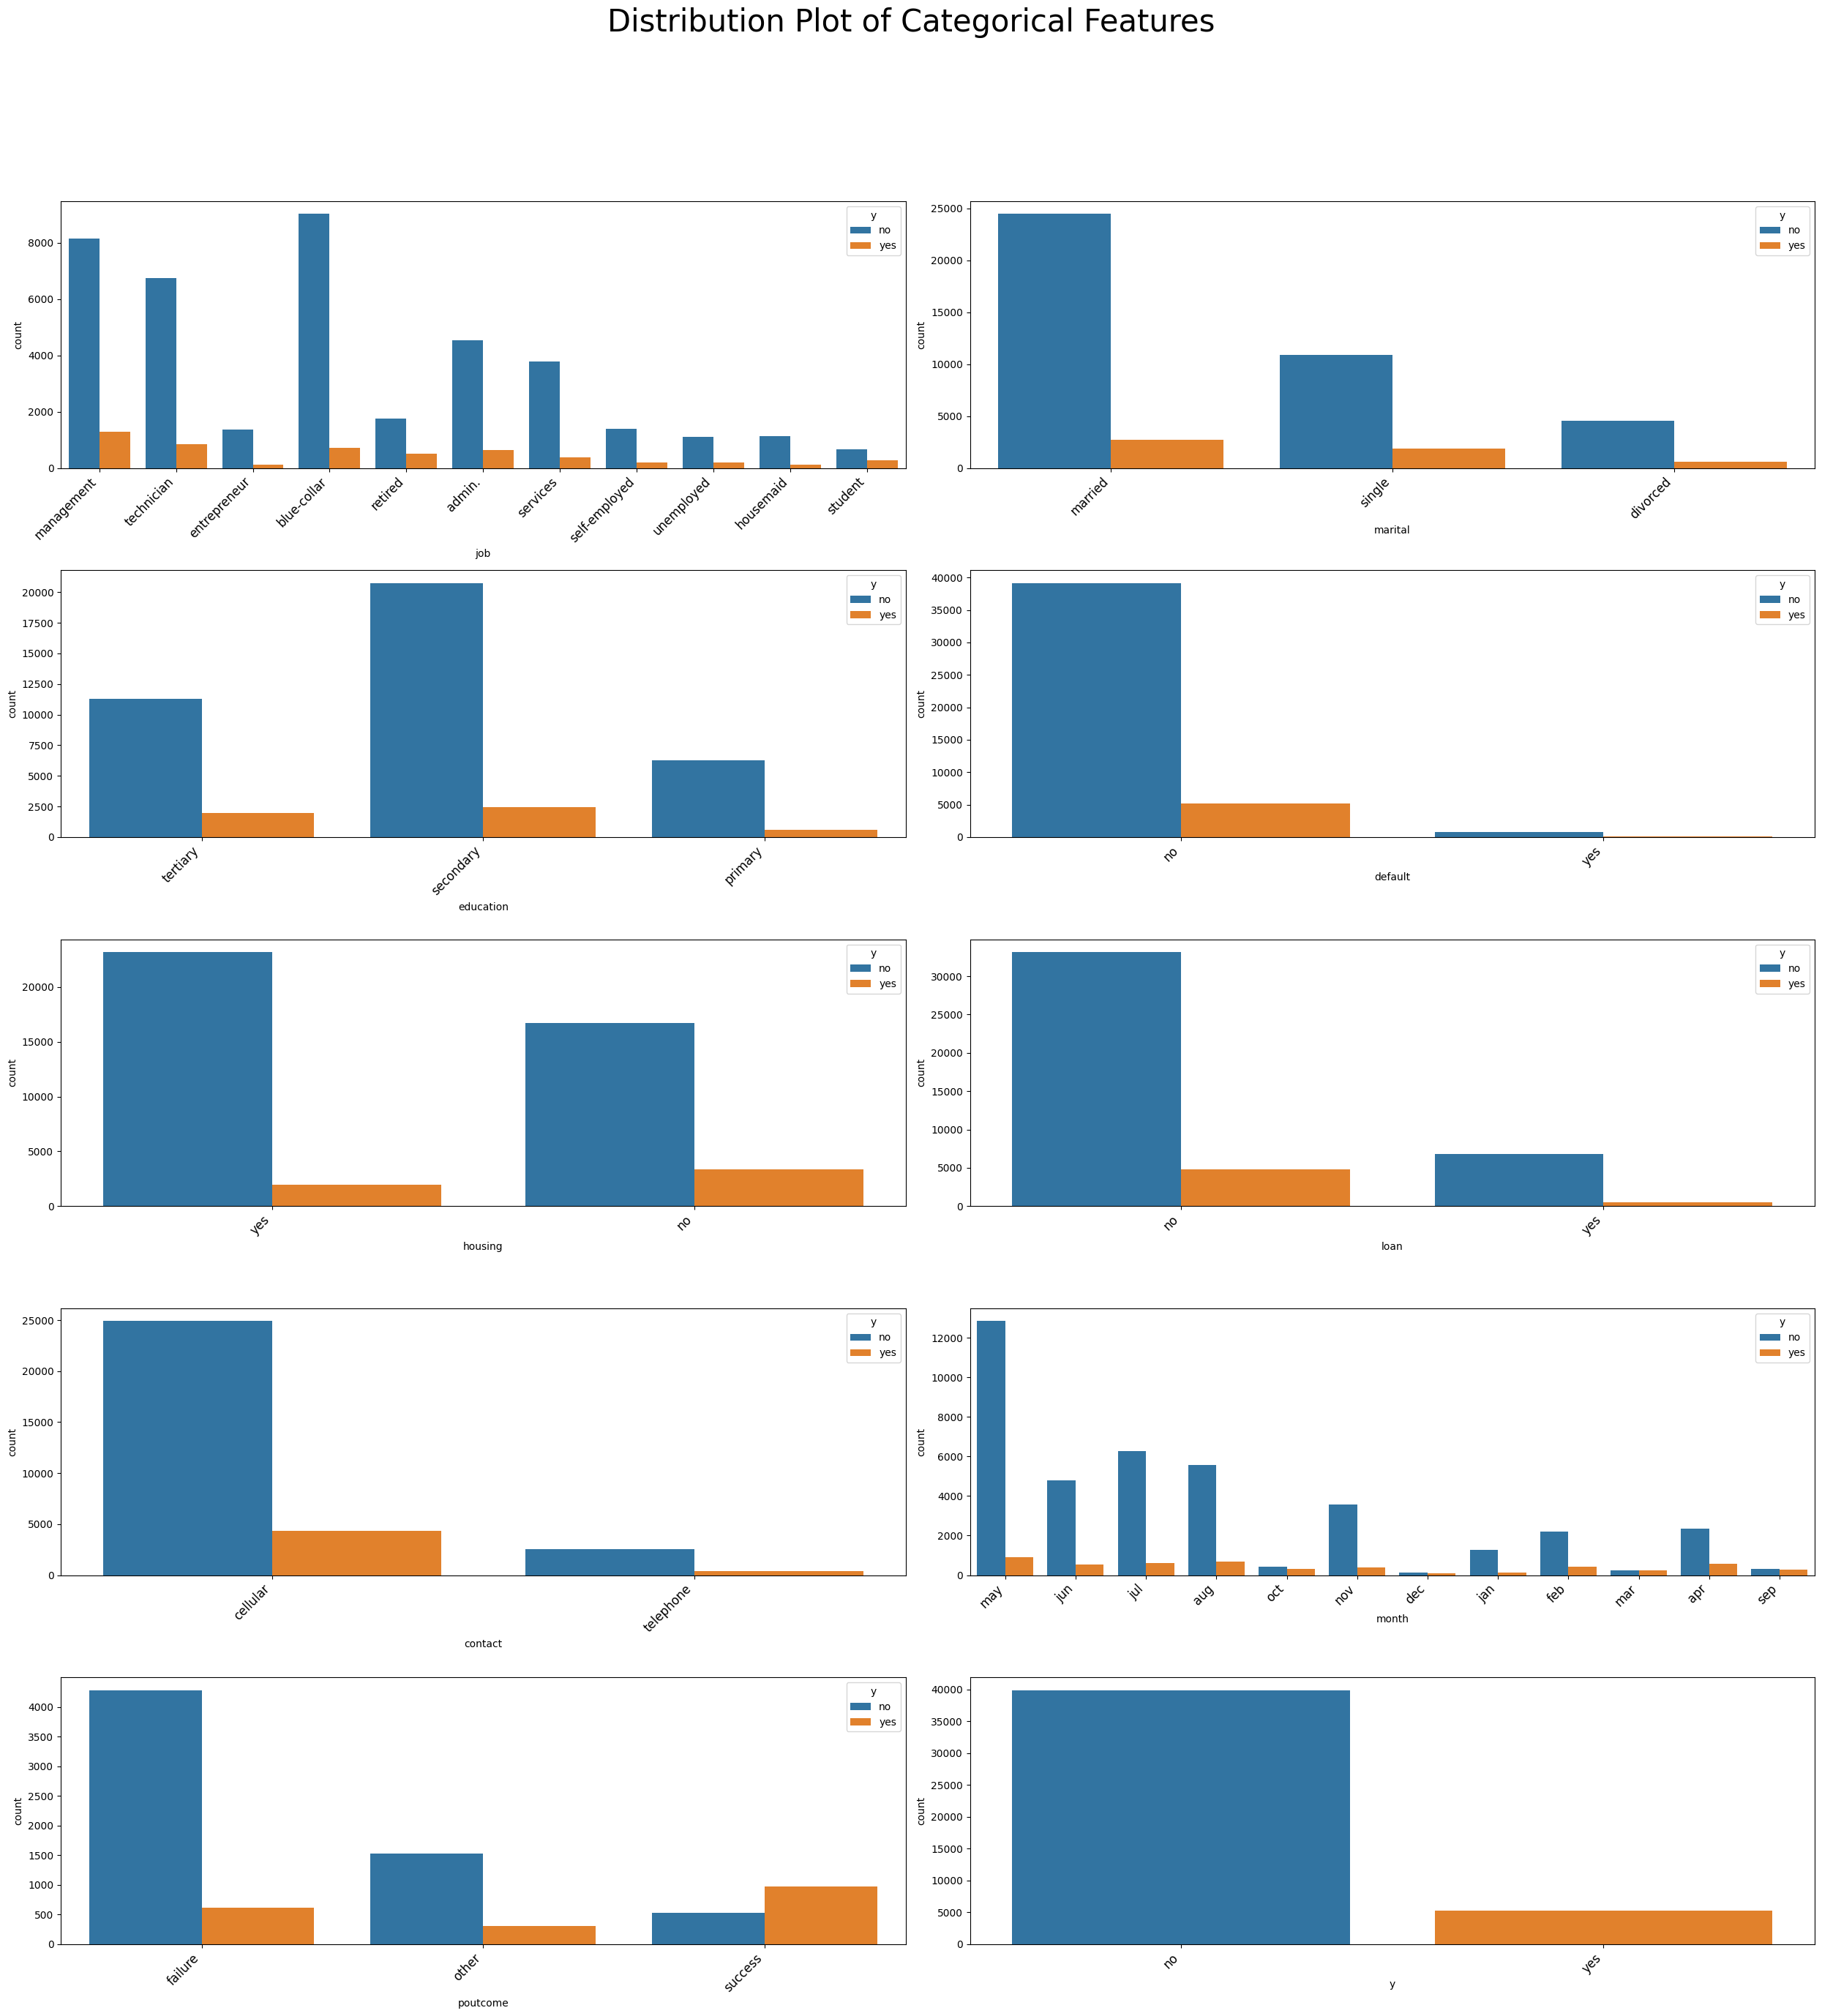

In [12]:
cat_column_1st =[]
for icol in df.columns:
    if df[icol].dtypes in['object']:
        cat_column_1st.append(icol)
print(cat_column_1st)

fig,axs= plt.subplots(nrows=5, ncols=2, figsize=(25,25))
for name, ax in zip(cat_column_1st, axs.flatten()):
    sns.countplot(data=df, x=name, ax=ax, hue='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,horizontalalignment='right',  fontsize=12)

fig.tight_layout()
fig.suptitle('Distribution Plot of Categorical Features',y= 1.1, fontsize=30)

'job': admin.blue-collar and management represent a large proportion of sample.
'marital': Married people have the lowest acceptance rate of all three categories.
'education':university is the most sampled education category.
'default':highest sampled is not with a relatively important category of unknown.
'housing':most people outreached have house
'loan': most people outreached have no loans
'contact': most people were contacted through cellphones
'month':most people were contacted in May,July,August and June.
This is important when predicting a model since the real conversion for the less sampled months can differ from those appearing  in the dataset since there are less than 1000 outreach during these months incontrast of nearly 14,000 in May. The difference could be due to rescheduled calls or other factors.
'day_of_week': relatively uniform across the days.
'poutcome': it seems that previous success outcomes are much more likely to accept the offer.


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


BUSINESS OBJECTIVE

The purpose of the analysis consist in leveraging the dataset supplied by a Portuguese Banking Institution regarding past direct marketing campaign. Using the daset of 17 campaigns, our plan is to create a model capable of predicting the success of marketing campaign. The success in this case is defined as the number of people accepting to purchase the product(along-term deposit with good interest rates).
The project will compare the classification methods:
- K-nearest neighbors (KNN)
- Logistic Regression (LR)
- Decision Trees (DT)
- Support Vector Machines (SVM)

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [14]:
DF= df[['age','job', 'marital', 'education', 'default', 'housing', 'loan', 'y']]
print(DF.shape)
DF.head()

(45211, 8)


,age,job,marital,education,default,housing,loan,y
0,58,management,married,tertiary,no,yes,no,no
1,44,technician,single,secondary,no,yes,no,no
2,33,entrepreneur,married,secondary,no,yes,yes,no
3,47,blue-collar,married,NaN,no,yes,no,no
4,33,NaN,single,NaN,no,no,no,no


In [15]:
#label Encode y to obtain a Boolean
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
DF.loc[:,'y'] = le.fit_transform(DF['y'])
DF.head()

,age,job,marital,education,default,housing,loan,y
0,58,management,married,tertiary,no,yes,no,0
1,44,technician,single,secondary,no,yes,no,0
2,33,entrepreneur,married,secondary,no,yes,yes,0
3,47,blue-collar,married,NaN,no,yes,no,0
4,33,NaN,single,NaN,no,no,no,0


In [16]:
# we will create a column transformer to deal with the categorical data and scale the numerical data. For the exception of age, all the columns are categorical and are non-binary (except y).
#The features 'job', 'marital', 'education', 'default', 'housing', and 'loan'  are not ordinal. We will create a transformer using OneHotEncoder and fit it to the DataFrame.

column_transformer = make_column_transformer((OneHotEncoder(drop='if_binary'),['job','marital','education', 'default','housing','loan']),
                                              (StandardScaler(),['age']),
                                              remainder='passthrough')
column_transformer.fit(DF)

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='if_binary'),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan']),
                                ('standardscaler', StandardScaler(), ['age'])])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [24]:
# Create X & y by splitting the data into 70/30 split
X= DF.drop (columns = 'y')
y= DF['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

# Explicitly convert y_train and y_test to integer type
y_train = y_train.astype(int)
y_test = y_test.astype(int)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [29]:
# Using a DummyClassifier with 'Most frequent' or the mode as the prediction

import pandas as pd
results_df = pd.DataFrame(columns=['Fit Time', 'Accuracy', 'ROC_AUC', 'F1', 'Precision', 'Recall'])
dummy_clf = DummyClassifier(strategy= 'most_frequent')
start= time.time()
dummy_clf.fit(X_train, y_train)
stop = time.time()

fit_time = str(round(stop-start, 2))+'s'
print(fit_time)
# Store fit time in results_df
results_df.loc['Baseline_Model', 'Fit Time'] = fit_time

0.01s


              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9950
           1       0.00      0.00      0.00      1353

    accuracy                           0.88     11303
   macro avg       0.44      0.50      0.47     11303
weighted avg       0.77      0.88      0.82     11303

ROC_AUC Score for Baseline= 0.5
False Positive Rates: [0. 1.]
True Positive Rates: [0. 1.]


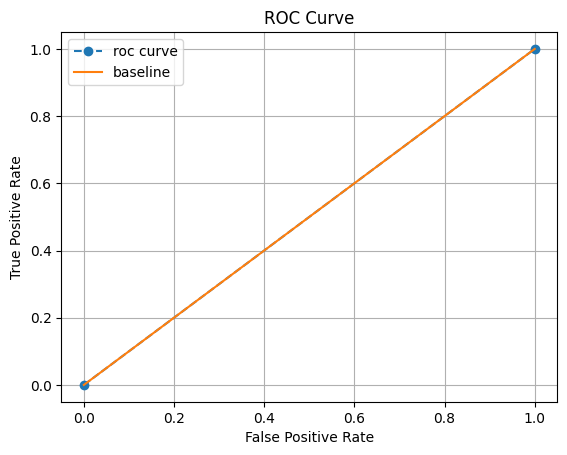

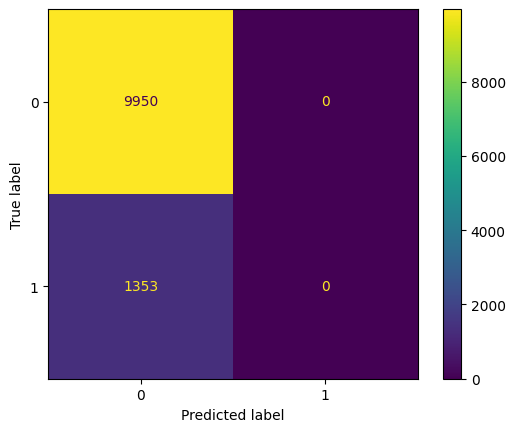

In [30]:
y_pred = dummy_clf.predict(X_test) # Get predicted class labels
y_proba = dummy_clf.predict_proba(X_test) # Get predicted probabilities

baseline_scores = classification_report(y_test, y_pred) # Use predicted labels here
print(baseline_scores)

baseline_roc_score= roc_auc_score(y_test, y_proba[:,1]) # Use probabilities for ROC AUC
print(f'ROC_AUC Score for Baseline= {baseline_roc_score}')

fpr,tpr, thresh_rocs= roc_curve(y_test, y_proba[:,1]) # Use probabilities for ROC curve
print('False Positive Rates:', fpr[:5])
print('True Positive Rates:', tpr[:min(len(tpr), 5)]) # Safely print the first 5 elements or fewer
plt.plot(fpr,tpr, '--o', label= 'roc curve')
plt.plot(tpr, tpr, label= 'baseline')
plt.legend()
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

results_df.loc['Baseline_Model', 'Accuracy']= accuracy_score(y_test, y_pred)
results_df.loc['Baseline_Model', 'ROC_AUC'] = baseline_roc_score
results_df.loc['Baseline_Model', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['Baseline_Model', 'Precision']= precision_score(y_test, y_pred)
results_df.loc['Baseline_Model', 'Recall']= recall_score(y_test, y_pred)

The model offers an accuracy of 88% and ROC_AUC of 0.5. This will be the baseline model for this analysis.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [32]:
X_train_simple= column_transformer.transform(X_train)
X_test_simple= column_transformer.transform(X_test)

simple_lgr = LogisticRegression()

start= time.time()
simple_lgr.fit(X_train_simple, y_train)
stop = time.time()

fit_time = str(round(stop-start, 2))+'s'
results_df.loc['Logistic Regression', 'Fit Time'] = fit_time

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9950
           1       0.00      0.00      0.00      1353

    accuracy                           0.88     11303
   macro avg       0.44      0.50      0.47     11303
weighted avg       0.77      0.88      0.82     11303

ROC_AUC Score for Logistic Regression= 0.5
False Positive Rates: [0.         0.         0.00020101 0.00030151 0.00040201]
True Positive Rates: [0.         0.0014782  0.0014782  0.0014782  0.00221729]


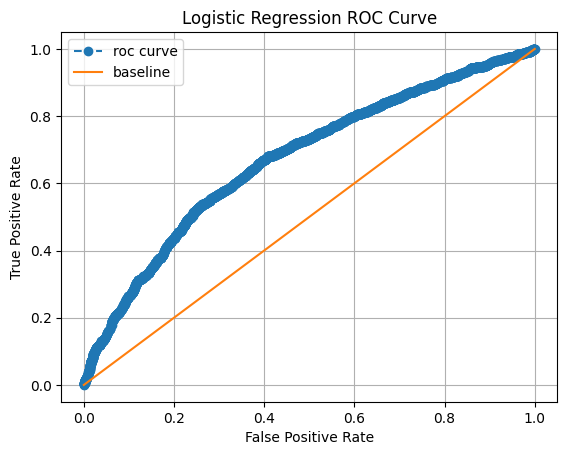

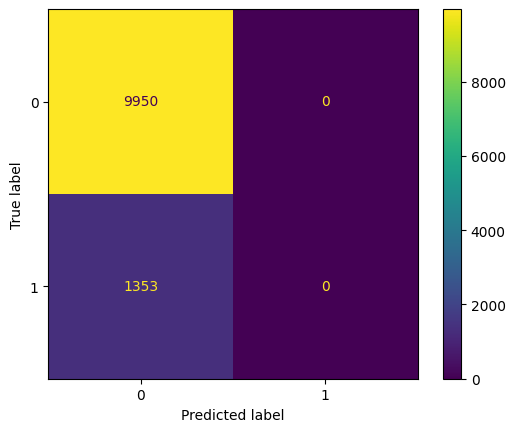

In [35]:
y_pred= simple_lgr.predict(X_test_simple)
y_pred_probs = simple_lgr.predict_proba(X_test_simple)

simple_lgr_scores = classification_report(y_test, y_pred)
print(simple_lgr_scores)

simple_lgr_roc_score= roc_auc_score(y_test, y_pred)
print(f'ROC_AUC Score for Logistic Regression= {simple_lgr_roc_score}')

fpr,tpr, thresh_rocs= roc_curve(y_test, y_pred_probs[:,1])
print('False Positive Rates:', fpr[:5])
print('True Positive Rates:', tpr[:5])
plt.plot(fpr,tpr, '--o', label= 'roc curve')
plt.plot(tpr, tpr, label= 'baseline')
plt.legend()
plt.title('Logistic Regression ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

results_df.loc['Logistic Regression', 'Accuracy']= accuracy_score(y_test, y_pred)
results_df.loc['Logistic Regression', 'ROC_AUC'] = simple_lgr_roc_score
results_df.loc['Logistic Regression', 'F1'] = f1_score(y_test, y_pred)
results_df.loc['Logistic Regression', 'Precision']= precision_score(y_test, y_pred)
results_df.loc['Logistic Regression', 'Recall']= recall_score(y_test, y_pred)


### Problem 9: Score the Model

What is the accuracy of your model?

In [36]:
start = time.time()
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)
stop = time.time()

predict_time_log_reg = str(round(stop - start, 2)) + 's'

print('Classification Report for Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg[:, 1])
print(f'ROC_AUC Score for Logistic Regression: {roc_auc_log_reg}')

results_df.loc['Logistic Regression', 'Accuracy'] = accuracy_score(y_test, y_pred_log_reg)
results_df.loc['Logistic Regression', 'ROC_AUC'] = roc_auc_log_reg
results_df.loc['Logistic Regression', 'F1'] = f1_score(y_test, y_pred_log_reg)
results_df.loc['Logistic Regression', 'Precision'] = precision_score(y_test, y_pred_log_reg)
results_df.loc['Logistic Regression', 'Recall'] = recall_score(y_test, y_pred_log_reg)

print('\nUpdated Results DataFrame:')
print(results_df)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9950
           1       0.00      0.00      0.00      1353

    accuracy                           0.88     11303
   macro avg       0.44      0.50      0.47     11303
weighted avg       0.77      0.88      0.82     11303

ROC_AUC Score for Logistic Regression: 0.6717321641466757

Updated Results DataFrame:
                    Fit Time  Accuracy   ROC_AUC   F1 Precision Recall
Baseline_Model         0.01s  0.880297       0.5  0.0       0.0    0.0
Logistic Regression     0.1s  0.880297  0.671732  0.0       0.0    0.0


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
# K-Nearest Neighbors (KNN)
knn_pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', KNeighborsClassifier())
])

start = time.time()
knn_pipeline.fit(X_train, y_train)
stop = time.time()
fit_time_knn = str(round(stop - start, 2)) + 's'
results_df.loc['K-Nearest Neighbors', 'Fit Time'] = fit_time_knn

y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)

results_df.loc['K-Nearest Neighbors', 'Accuracy'] = accuracy_score(y_test, y_pred_knn)
results_df.loc['K-Nearest Neighbors', 'ROC_AUC'] = roc_auc_score(y_test, y_proba_knn[:, 1])
results_df.loc['K-Nearest Neighbors', 'F1'] = f1_score(y_test, y_pred_knn)
results_df.loc['K-Nearest Neighbors', 'Precision'] = precision_score(y_test, y_pred_knn)
results_df.loc['K-Nearest Neighbors', 'Recall'] = recall_score(y_test, y_pred_knn)

print('K-Nearest Neighbors (KNN) Performance:')
print(classification_report(y_test, y_pred_knn))
print(f'ROC_AUC Score: {roc_auc_score(y_test, y_proba_knn[:, 1])}')

# Decision Tree
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

start = time.time()
decision_tree_pipeline.fit(X_train, y_train)
stop = time.time()
fit_time_dt = str(round(stop - start, 2)) + 's'
results_df.loc['Decision Tree', 'Fit Time'] = fit_time_dt

y_pred_dt = decision_tree_pipeline.predict(X_test)
y_proba_dt = decision_tree_pipeline.predict_proba(X_test)

results_df.loc['Decision Tree', 'Accuracy'] = accuracy_score(y_test, y_pred_dt)
results_df.loc['Decision Tree', 'ROC_AUC'] = roc_auc_score(y_test, y_proba_dt[:, 1])
results_df.loc['Decision Tree', 'F1'] = f1_score(y_test, y_pred_dt)
results_df.loc['Decision Tree', 'Precision'] = precision_score(y_test, y_pred_dt)
results_df.loc['Decision Tree', 'Recall'] = recall_score(y_test, y_pred_dt)

print('\nDecision Tree Performance:')
print(classification_report(y_test, y_pred_dt))
print(f'ROC_AUC Score: {roc_auc_score(y_test, y_proba_dt[:, 1])}')

# Support Vector Machine (SVC)
svc_pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('classifier', SVC(probability=True, random_state=42))
])

start = time.time()
svc_pipeline.fit(X_train, y_train)
stop = time.time()
fit_time_svc = str(round(stop - start, 2)) + 's'
results_df.loc['Support Vector Machine', 'Fit Time'] = fit_time_svc

y_pred_svc = svc_pipeline.predict(X_test)
y_proba_svc = svc_pipeline.predict_proba(X_test)

results_df.loc['Support Vector Machine', 'Accuracy'] = accuracy_score(y_test, y_pred_svc)
results_df.loc['Support Vector Machine', 'ROC_AUC'] = roc_auc_score(y_test, y_proba_svc[:, 1])
results_df.loc['Support Vector Machine', 'F1'] = f1_score(y_test, y_pred_svc)
results_df.loc['Support Vector Machine', 'Precision'] = precision_score(y_test, y_pred_svc)
results_df.loc['Support Vector Machine', 'Recall'] = recall_score(y_test, y_pred_svc)

print('\nSupport Vector Machine (SVC) Performance:')
print(classification_report(y_test, y_pred_svc))
print(f'ROC_AUC Score: {roc_auc_score(y_test, y_proba_svc[:, 1])}')

print('\nFinal Results DataFrame:')
print(results_df)

K-Nearest Neighbors (KNN) Performance:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93      9950
           1       0.24      0.07      0.11      1353

    accuracy                           0.86     11303
   macro avg       0.56      0.52      0.52     11303
weighted avg       0.81      0.86      0.83     11303

ROC_AUC Score: 0.5980875552930952

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93      9950
           1       0.23      0.06      0.09      1353

    accuracy                           0.86     11303
   macro avg       0.56      0.52      0.51     11303
weighted avg       0.81      0.86      0.83     11303

ROC_AUC Score: 0.6126462690392093

Support Vector Machine (SVC) Performance:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9950
           1       0.18      0.00      0.00      1353

    

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions